In [7]:
'''
    Neural network states for quantum spin models
    Honeycomb lattice Tripod model (containing Ising, Kitaev, and Heisenberg model in three limits)
    L*L cluster, with periodic boundary conditions
    Either Restricted Boltzmann Machine or Feed Forward Neural Network
    
    Goal: 
    To determine the phase diagram

    Known issues:
    1. The iteration may have numerical instability: the energy goes negative and large, or diverges (nan).
    2. MPI with multiple cores on Argo does not always finish cleanly, and sometimes hangs, especially when in a loop.
    
    Warning:
    3. Around the kitaev point, ~3000 iterations are required for learning rate 0.01, must check the convergence.
    4. For computing the observables, one should use a large n_sample and small learning rate.
    
    python 3.8 and netket 2.1
    Erhai Zhao, 2021
    
'''

# import the utility libraries
import netket as nk
import numpy as np
import math
import json

# a constant, square root of 3
R3 = math.sqrt(3.0)
ToRadiant = math.pi/180.0

# number of unit cells in the cluster: L*L
L = 4

# set up the honeycomb lattice
g=nk.graph.Lattice(basis_vectors=[[1.5,0.5*R3],[0,R3]],extent=[L,L],
                   pbc=[True,True],atoms_coord=[[0,0],[1,0]]) 

# Hilbert space for spin 1/2 
# confined to S_z=0 sector, sufficient for ground state.
hi = nk.hilbert.Spin(graph=g, s=0.5, total_sz=0)

# Pauli Matrices
sigmaz = np.array([[1, 0], [0, -1]])
sigmax = np.array([[0, 1], [1, 0]])
sigmay = np.array([[0, -1j], [1j, 0]])

# theta angle, in degrees:
# theta = 90 (Ising limit)
# theta = 0 (120-degree model limit)
#theta = 90
#angl = theta*ToRadiant 

# this realizes the Kitaev model
angl = math.acos(math.sqrt(2.0/3.0))

cs = math.cos(angl)
sn = math.sin(angl)

# theta prime
thetaprime = math.acos(1.0 - 1.5*cs**2)
# in degrees
print(thetaprime/ToRadiant)

# three spin operators in the tripod model, as defined in NJP, Zou et al.
t1 = sigmaz*cs + sigmay*sn
t2 = sigmaz*(-cs*0.5) + sigmax*( cs*0.5*R3) + sigmay*sn
t3 = sigmaz*(-cs*0.5) + sigmax*(-cs*0.5*R3) + sigmay*sn

# Number of sites 
Ns=g.n_sites
# must be even
assert Ns % 2 == 0

# number of unit cells
Nu = int(Ns/2)

# shifting needed going from A to the B site
shift = Nu

# empty lists to store the sites (pair) and the corresponding operators (exchange interaction)
operators = []
sites = []

# loop over the unit cells
for i in range(Nu):
    
    # horizontal bond, (t1, t1) coupling
    sites.append([i, (i+shift)])
    operators.append((np.kron(t1,t1)).tolist())
    
    # lattice coordinates
    [m,n] = g.site_to_vector(i) 
    
    # northeast-southwest bond, (t2, t2) coupling
    # the unit cell, shift m to left (-1), modulo L 
    newvec = [(m-1)%L,n] 
    k = g.vector_to_site(newvec)
    sites.append([i,(k+shift)])
    operators.append((np.kron(t2,t2)).tolist())
    
    # northwest-southeast bond, (t3,t3) coupling    
    newvec = [(m-1)%L,(n+1)%L]
    k = g.vector_to_site(newvec)
    sites.append([i,(k+shift)])
    operators.append((np.kron(t3,t3)).tolist())
    
# define the Hamiltonian using the sites and operators
ham = nk.operator.LocalOperator(hi, operators=operators, acting_on=sites)

# define observables
observers = {}

# average of bond energy (dimer), for each bond from site iA to iB
for i in range(Nu):
    
    ss = np.kron(t1,t1)
    dimer = nk.operator.LocalOperator(hi, operators=[ss.tolist()], acting_on=[[i,(i+shift)]])
    observers.update({'d1'+str(i): dimer})
    
    # lattice coordinates
    [m,n] = g.site_to_vector(i) 
    
    newvec = [(m-1)%L,n] 
    k = g.vector_to_site(newvec)
    ss = np.kron(t2,t2)
    dimer = nk.operator.LocalOperator(hi, operators=[ss.tolist()], acting_on=[[i,(k+shift)]])
    observers.update({'d2'+str(i): dimer})    
    
    newvec = [(m-1)%L,(n+1)%L]
    k = g.vector_to_site(newvec)
    ss = np.kron(t3,t3)
    dimer = nk.operator.LocalOperator(hi, operators=[ss.tolist()], acting_on=[[i,(k+shift)]])
    observers.update({'d3'+str(i): dimer})  
        
# average of local spin x, y, z, going over all sites
for i in range(Ns):
    observers.update({'x'+str(i): nk.operator.LocalOperator(hi, operators=[sigmax.tolist()], acting_on=[[i]])})
    observers.update({'y'+str(i): nk.operator.LocalOperator(hi, operators=[sigmay.tolist()], acting_on=[[i]])})
    observers.update({'z'+str(i): nk.operator.LocalOperator(hi, operators=[sigmaz.tolist()], acting_on=[[i]])})
    
# Define the RBM machine, with alpha = 2
ma = nk.machine.RbmSpin(hilbert=hi, alpha=2, use_visible_bias=True)
#ma.init_random_parameters(seed=1234, sigma=0.01)
ma.init_random_parameters(seed=2211, sigma=0.02)
# specify sampler
sa = nk.sampler.MetropolisExchange(ma)
#sa = nk.sampler.MetropolisLocal(ma)

'''
# FFNN 
alpha = 2
layers = (nk.layer.FullyConnected(input_size=Ns,output_size=int(alpha*Ns),use_bias=True),
          nk.layer.Lncosh(input_size=int(alpha*Ns)),
          nk.layer.SumOutput(input_size=int(alpha*Ns))
         )
for layer in layers:
    layer.init_random_parameters(sigma=0.01)
ffnn = nk.machine.FFNN(hi, layers)
#print("The FFNN machine has", ffnn.n_par, "parameters.")
# specify sampler
sa = nk.sampler.MetropolisExchange(machine=ffnn)
'''

# Optimizer, stochastic gradient descent
op=nk.optimizer.Sgd(learning_rate=0.01,decay_factor=1)

#op=nk.optimizer.AdaMax()
#op=nk.optimizer.AdaGrad()
    
# VMC via Stochastic Reconfiguration to ground state
gs = nk.variational.Vmc(
    hamiltonian=ham,
    sampler=sa,
    optimizer=op,
    n_samples=1000,
    diag_shift=0.1,
    use_iterative=True,
    method='Sr')

# less than 2 seconds per iteration
gs.run(out='RBM0', n_iter=1000) #, obs=observers)
#print(gs.energy)

  0%|          | 0/1000 [00:00<?, ?it/s]

90.0


100%|██████████| 1000/1000 [33:09<00:00,  1.99s/it, Energy=(-23.121 + 0.179i) ± 0.096 [var=6.102, R=1.00425]]


In [3]:
# increase the MC sampling on the fly
# According to arXiv/2003.07280, the exact energy is E = -25.4164")


op=nk.optimizer.AdaMax()
gs.optimizer=op

gs.n_samples = 5000
gs.run(out='RBM', n_iter=50, obs=observers)

100%|██████████| 50/50 [15:30<00:00, 18.61s/it, Energy=(-24.82 + 0.01i) ± 0.12 [var=0.90, R=1.11358]]    


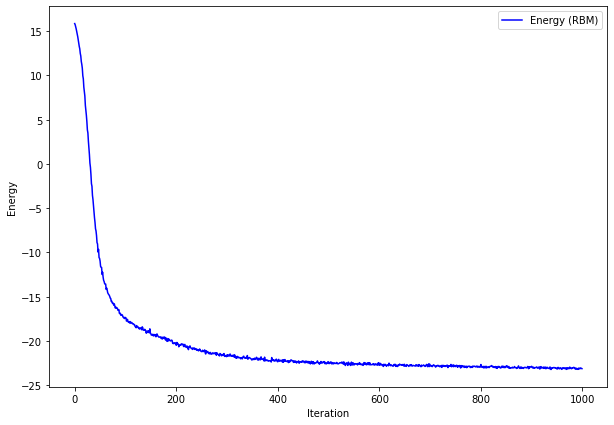

In [8]:
# plot the energy for all iteration steps

import matplotlib.pyplot as plt
import json

en = []
st = []
data=json.load(open("RBM0.log"))

for iteration in data["Output"]:
    en.append(iteration["Energy"]["Mean"])
    st.append(iteration["Iteration"])

fig, ax1 = plt.subplots(figsize=(10,7))
ax1.plot(st, en, color='blue', label='Energy (RBM)')
ax1.set_ylabel('Energy')
ax1.set_xlabel('Iteration')

ax1.legend()
plt.show()

According to arXiv/2003.07280, the exact energy is E = -25.4164
Here, the average energy is  E = -24.67108162422826


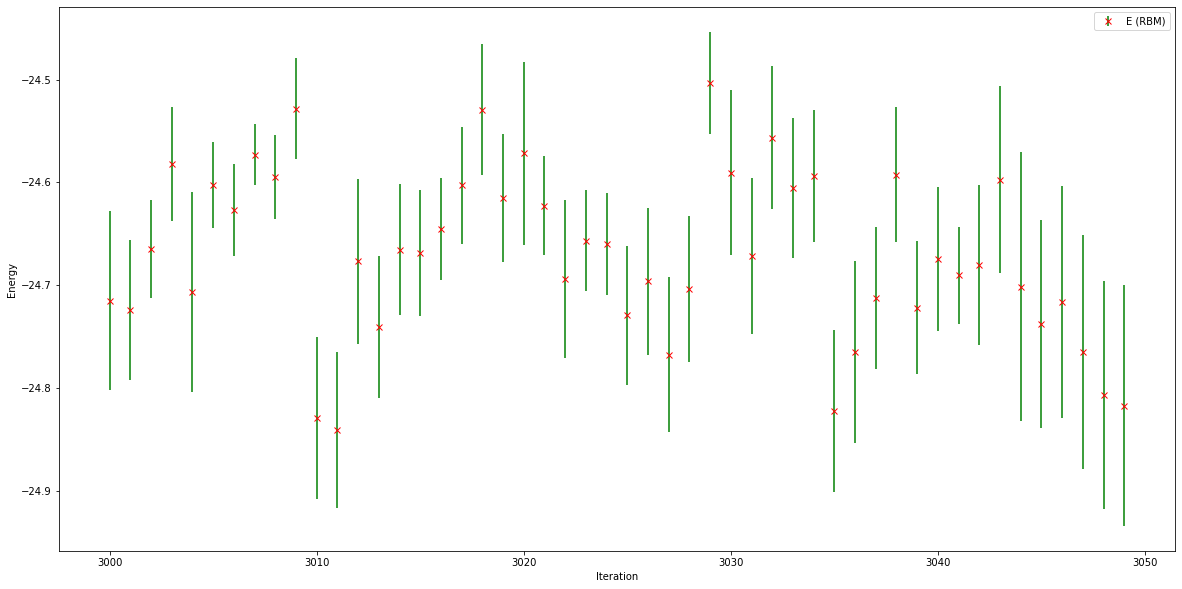

In [6]:
# plot the energy and its "standard deviation" 

import statistics
en = []
de = []
st = []

data=json.load(open("RBM.log"))
    
for iteration in data["Output"]:
    en.append(iteration["Energy"]["Mean"])
    de.append(iteration["Energy"]["Sigma"])
    st.append(iteration["Iteration"])

print("According to arXiv/2003.07280, the exact energy is E = -25.4164")
print("Here, the average energy is  E =", statistics.mean(en))        
      
fig, ax1 = plt.subplots(figsize=(20,10))
ax1.errorbar(st, en, yerr=de, color='r', label='E (RBM)', fmt='x', ecolor='g', capthick=1)
ax1.set_ylabel('Energy')
ax1.set_xlabel('Iteration')

ax1.legend()
plt.show()

In [8]:
# plot the energy and its fluctuation, the last 400 iterations

import statistics
en = []
de = []
st = []

data=json.load(open("RBM.log"))

for i in range(Nu):
    bond1 = []
    bond2 = []
    bond3 = []
    
    for iteration in data["Output"]:
        bond1.append(iteration['d1'+str(i)]["Mean"])
        bond2.append(iteration['d2'+str(i)]["Mean"])
        bond3.append(iteration['d3'+str(i)]["Mean"])

    d1 = statistics.mean(bond1)
    d2 = statistics.mean(bond2)
    d3 = statistics.mean(bond3)
    
    print(i,"  ", d1, "  ", d2,"  ",d3)

0    -0.5847282364647121    -0.4866407849250744    -0.4687699680511182
1    -0.5976788723437874    -0.44192264158114225    -0.5039297124600639
2    -0.5718851605343453    -0.4577506595007769    -0.5084744408945687
3    -0.5668561215554497    -0.46981500822621625    -0.5169728434504792
4    -0.5911199448793989    -0.44558708391749036    -0.48850638977635785
5    -0.5895603902258546    -0.44911255924012966    -0.4853993610223642
6    -0.5912075053700312    -0.47132300611797795    -0.4884664536741214
7    -0.5528415786153845    -0.5066442388957043    -0.4913977635782748
8    -0.5721770497365319    -0.4626972359150233    -0.48855431309904157
9    -0.5805231736238001    -0.4639021266518668    -0.4902156549520767
10    -0.5927796945178013    -0.4704803775281905    -0.500255591054313
11    -0.570757344282368    -0.475646146008277    -0.5030591054313099
12    -0.582918110820019    -0.4577143531514839    -0.49028753993610225
13    -0.5862792402592877    -0.4804931897915111    -0.50685303514377


In [10]:
# plot the energy and its fluctuation, the last 400 iterations

import statistics

data=json.load(open("RBM.log"))

for i in range(Nu):
    sx = []
    sy = []
    sz = []
    
    for iteration in data["Output"]:
        sx.append(iteration['x'+str(i)]["Mean"])
        sy.append(iteration['y'+str(i)]["Mean"])
        sz.append(iteration['z'+str(i)]["Mean"])

    d1 = statistics.mean(sx)
    d2 = statistics.mean(sy)
    d3 = statistics.mean(sz)
    
    print(i,"  ", d1, "  ", d2,"  ",d3)
    
for i in range(Nu,Ns):
    sx = []
    sy = []
    sz = []
    
    for iteration in data["Output"]:
        sx.append(iteration['x'+str(i)]["Mean"])
        sy.append(iteration['y'+str(i)]["Mean"])
        sz.append(iteration['z'+str(i)]["Mean"])

    d1 = statistics.mean(sx)
    d2 = statistics.mean(sy)
    d3 = statistics.mean(sz)
    
    print(i,"  ", d1, "  ", d2,"  ",d3)

0    0.09274518636826135    -0.09343323151812288    0.10956070287539937
1    -0.016898769664475854    0.10972263939017261    -0.008202875399361022
2    0.055726718915758235    -0.10316977304453587    0.014241214057507988
3    0.09074220210890716    0.08500096037504465    -0.051517571884984036
4    -0.08727143967149195    -0.11188284540518033    -0.01254792332268371
5    0.009707424593712365    0.10831680496176635    -0.06324281150159744
6    -0.05026583230973163    -0.1077560142138037    0.006996805111821086
7    -0.09871706752370941    0.08131120589196739    0.0669968051118211
8    0.09137080987663941    -0.1126430469049798    -0.09546325878594249
9    -0.01748398869447841    0.10367415080225205    0.0037460063897763575
10    0.059588851413879    -0.11362441012854758    0.04945686900958466
11    0.09146432588476358    0.08155856771332261    -0.03031150159744409
12    -0.08970595665944577    -0.11305526171574246    -0.01925718849840255
13    0.01091251491677504    0.1090584106948732   

In [2]:
# check the basics
print(g.n_dim)
print(g.n_sites)
print(g.is_bipartite)
print(hi.size)

2
32
True
32


In [3]:
# check the ordering of sites 
# (m,n): first comes sublattice A, then B
for i in range(g.n_sites): 
    print(g.site_to_vector(i))

[0, 0]
[0, 1]
[0, 2]
[0, 3]
[1, 0]
[1, 1]
[1, 2]
[1, 3]
[2, 0]
[2, 1]
[2, 2]
[2, 3]
[3, 0]
[3, 1]
[3, 2]
[3, 3]
[0, 0]
[0, 1]
[0, 2]
[0, 3]
[1, 0]
[1, 1]
[1, 2]
[1, 3]
[2, 0]
[2, 1]
[2, 2]
[2, 3]
[3, 0]
[3, 1]
[3, 2]
[3, 3]


In [4]:
# check the (x,y) coordinates of the sites
for i in range(g.n_sites): 
    print(g.site_to_coord(i))

[0.0, 0.0]
[0.0, 1.7320508075688772]
[0.0, 3.4641016151377544]
[0.0, 5.196152422706632]
[1.5, 0.8660254037844386]
[1.5, 2.598076211353316]
[1.5, 4.330127018922193]
[1.5, 6.06217782649107]
[3.0, 1.7320508075688772]
[3.0, 3.4641016151377544]
[3.0, 5.196152422706632]
[3.0, 6.928203230275509]
[4.5, 2.598076211353316]
[4.5, 4.330127018922193]
[4.5, 6.06217782649107]
[4.5, 7.794228634059948]
[1.0, 0.0]
[1.0, 1.7320508075688772]
[1.0, 3.4641016151377544]
[1.0, 5.196152422706632]
[2.5, 0.8660254037844386]
[2.5, 2.598076211353316]
[2.5, 4.330127018922193]
[2.5, 6.06217782649107]
[4.0, 1.7320508075688772]
[4.0, 3.4641016151377544]
[4.0, 5.196152422706632]
[4.0, 6.928203230275509]
[5.5, 2.598076211353316]
[5.5, 4.330127018922193]
[5.5, 6.06217782649107]
[5.5, 7.794228634059948]


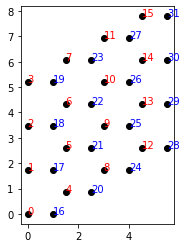

In [9]:
# checking the lattice
# plot the sites and show its index

import netket as nk
import math 
import matplotlib.pyplot as plt

# a constant, square root of 3
R3 = math.sqrt(3.0)

# number of unit cells in the cluster: L*L
L = 4

# set up the honeycomb lattice
g=nk.graph.Lattice(basis_vectors=[[1.5,0.5*R3],[0,R3]],extent=[L,L],
                   pbc=[True,True],atoms_coord=[[0,0],[1,0]]) 

x = [g.site_to_coord(i)[0] for i in range(g.n_sites)]
y = [g.site_to_coord(i)[1] for i in range(g.n_sites)]
fig = plt.figure()
ax = fig.add_subplot(111)
ax.set_aspect('equal')
plt.plot(x, y, 'o', color='black')

# color code: A sublattice red, B sublattice blue
for i in range(g.n_sites): 
    [xi,yi] = g.site_to_coord(i)
    ax.text(xi, yi, str(i), color='red' if i<16 else 'blue')
    
plt.show()    

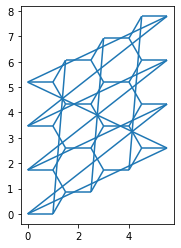

In [6]:
# check the edges and periodic boundary condition 
# each site should have three bonds

from matplotlib.collections import LineCollection 

lines = []
for eg in g.edges: 
    (x1,y1) = g.site_to_coord(eg[0])
    (x2,y2) = g.site_to_coord(eg[1])
    lines.append([(x1,y1),(x2,y2)])
    
lc = LineCollection(lines)
fig, ax = plt.subplots()
ax.add_collection(lc)
ax.autoscale()
ax.set_aspect('equal')

plt.show()

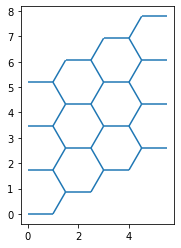

In [7]:
# compare: open boundary condition

gopen=nk.graph.Lattice(basis_vectors=[[1.5,0.5*R3],[0,R3]],extent=[4,4],pbc=[False,False],
                   atoms_coord=[[0,0],[1,0]]) 

lines = []
for eg in gopen.edges: 
    (x1,y1) = gopen.site_to_coord(eg[0])
    (x2,y2) = gopen.site_to_coord(eg[1])
    lines.append([(x1,y1),(x2,y2)])
    
lc = LineCollection(lines)
fig, ax = plt.subplots()
ax.add_collection(lc)
ax.autoscale()
ax.set_aspect('equal')
plt.show()

In [6]:
import math
math.acos(math.sqrt(2.0/3.0))*180/math.pi

35.264389682754654

In [ ]:
'''
    Neural network states for quantum spin models
    Tripod model (containing Ising, Kitaev, and Heisenberg model in three limits) on honeycomb lattice 
    L*L cluster, with periodic boundary conditions
    Either Restricted Boltzmann Machine (RBM)
    Or Feed Forward Neural Network (FFNN)
    
    Goal: 
    To determine the phase diagram

    Known issues:
    1. The iteration may have numerical instability: the energy goes negative and large, or diverges (nan). Discard the result when this occurs.
    2. MPI with multiple cores on Argo does not always finish cleanly, and sometimes hangs, especially when in a loop or using large n_samples. One may need to scancel the tasks.
    
    Warning:
    3. Around the kitaev point, ~3000 iterations are required for learning rate 0.01, must check the convergence with care.
    4. For computing the observables, one should use a large n_sample and small learning rate.
    
    python 3.8 and netket 2.1
    Erhai Zhao, 2021
    
'''

# import the utility libraries
import netket as nk
import numpy as np
import math
import json

# a constant, square root of 3
R3 = math.sqrt(3.0)
ToRadiant = math.pi/180.0

# number of unit cells in the cluster: L*L
L = 4

# set up the honeycomb lattice
g=nk.graph.Lattice(basis_vectors=[[1.5,0.5*R3],[0,R3]],extent=[L,L],
                   pbc=[True,True],atoms_coord=[[0,0],[1,0]]) 
# Number of sites 
Ns=g.n_sites
# must be even
assert Ns % 2 == 0

# number of unit cells
Nu = int(Ns/2)

# shifting needed going from A to the B site
shift = Nu

# Hilbert space for spin 1/2 
# confined to S_z=0 sector, sufficient for ground state.
hi = nk.hilbert.Spin(graph=g, s=0.5, total_sz=0)

# Pauli Matrices
sigmaz = np.array([[1, 0], [0, -1]])
sigmax = np.array([[0, 1], [1, 0]])
sigmay = np.array([[0, -1j], [1j, 0]])

# theta angle, in degrees:
# theta = 90 (Ising limit)
# theta = 0 (120-degree model limit)
# this realizes the Kitaev model:
# angl = math.acos(math.sqrt(2.0/3.0))
# or 35.2644 degrees

# define a function, for a given theta [90,0]
# set computeobs=true to compute the observables (provided that the iterations have already achieves convergence)
# set computeobs=false to run the learning iterations, at a faster speed, only monitoring energy
def learn(theta, computeobs):
    
    if computeobs:
        ns = 5000 # n_samples
        lr = 0.002 # learning_rate, maybe should use adagrad, adamax etc.
    else:
        ns = 1000
        lr = 0.01

    angl = theta*ToRadiant 
    cs = math.cos(angl)
    sn = math.sin(angl)

    # theta prime
    # thetaprime = math.acos(1.0 - 1.5*cs**2)
    # in degrees
    # print(thetaprime/ToRadiant)

    # three spin operators in the tripod model, as defined in NJP, Zou et al.
    t1 = sigmaz*cs + sigmay*sn
    t2 = sigmaz*(-cs*0.5) + sigmax*( cs*0.5*R3) + sigmay*sn
    t3 = sigmaz*(-cs*0.5) + sigmax*(-cs*0.5*R3) + sigmay*sn

    # empty lists to store the sites (pair) and the corresponding operators (exchange interaction)
    operators = []
    sites = []

    # loop over the unit cells
    for i in range(Nu):

        # horizontal bond, (t1, t1) coupling
        sites.append([i, (i+shift)])
        operators.append((np.kron(t1,t1)).tolist())

        # lattice coordinates
        [m,n] = g.site_to_vector(i) 

        # northeast-southwest bond, (t2, t2) coupling
        # the unit cell, shift m to left (-1), modulo L 
        newvec = [(m-1)%L,n] 
        k = g.vector_to_site(newvec)
        sites.append([i,(k+shift)])
        operators.append((np.kron(t2,t2)).tolist())

        # northwest-southeast bond, (t3,t3) coupling    
        newvec = [(m-1)%L,(n+1)%L]
        k = g.vector_to_site(newvec)
        sites.append([i,(k+shift)])
        operators.append((np.kron(t3,t3)).tolist())

    # define the Hamiltonian using the sites and operators
    ham = nk.operator.LocalOperator(hi, operators=operators, acting_on=sites)

    # define observables
    observers = {}

    # average of bond energy (dimer), for each bond from site iA to iB
    for i in range(Nu):

        ss = np.kron(t1,t1)
        dimer = nk.operator.LocalOperator(hi, operators=[ss.tolist()], acting_on=[[i,(i+shift)]])
        observers.update({'d1'+str(i): dimer})

        # lattice coordinates
        [m,n] = g.site_to_vector(i) 

        newvec = [(m-1)%L,n] 
        k = g.vector_to_site(newvec)
        ss = np.kron(t2,t2)
        dimer = nk.operator.LocalOperator(hi, operators=[ss.tolist()], acting_on=[[i,(k+shift)]])
        observers.update({'d2'+str(i): dimer})    

        newvec = [(m-1)%L,(n+1)%L]
        k = g.vector_to_site(newvec)
        ss = np.kron(t3,t3)
        dimer = nk.operator.LocalOperator(hi, operators=[ss.tolist()], acting_on=[[i,(k+shift)]])
        observers.update({'d3'+str(i): dimer})  

    # average of local spin x, y, z, going over all sites
    for i in range(Ns):
        observers.update({'x'+str(i): nk.operator.LocalOperator(hi, operators=[sigmax.tolist()], acting_on=[[i]])})
        observers.update({'y'+str(i): nk.operator.LocalOperator(hi, operators=[sigmay.tolist()], acting_on=[[i]])})
        observers.update({'z'+str(i): nk.operator.LocalOperator(hi, operators=[sigmaz.tolist()], acting_on=[[i]])})

    # Define the RBM machine, with alpha = 2
    ma = nk.machine.RbmSpin(hilbert=hi, alpha=2, use_visible_bias=True)

    if computeobs:
        # for compute observable
        fn = '/scratch/ezhao2/RBM-ITE-'+str(theta)+'.wf'
        ma.load(fn)
    else:
        # random initialization, for run iteration    
        #ma.init_random_parameters(seed=1234, sigma=0.01)
        ma.init_random_parameters(sigma=0.02)


    # specify sampler
    sa = nk.sampler.MetropolisExchange(ma)
    #sa = nk.sampler.MetropolisLocal(ma)

    '''
    # FFNN 
    alpha = 2
    layers = (nk.layer.FullyConnected(input_size=Ns,output_size=int(alpha*Ns),use_bias=True),
              nk.layer.Lncosh(input_size=int(alpha*Ns)),
              nk.layer.SumOutput(input_size=int(alpha*Ns))
             )
    for layer in layers:
        layer.init_random_parameters(sigma=0.01)
    ffnn = nk.machine.FFNN(hi, layers)
    #print("The FFNN machine has", ffnn.n_par, "parameters.")
    # specify sampler
    sa = nk.sampler.MetropolisExchange(machine=ffnn)
    '''

    # Optimizer, stochastic gradient descent
    op=nk.optimizer.Sgd(learning_rate=lr,decay_factor=1) 
    # change from 0.01 to 0.002 when computing observables

    #op=nk.optimizer.AdaMax()
    #op=nk.optimizer.AdaGrad()

    # VMC via Stochastic Reconfiguration to ground state
    gs = nk.variational.Vmc(
        hamiltonian=ham,
        sampler=sa,
        optimizer=op,
        n_samples=ns, # change 1000 to 5000 for computing the observables
        diag_shift=0.1,
        use_iterative=True,
        method='Sr')

    if computeobs:
        # compute the observables
        gs.run(out='/scratch/ezhao2/RBM-OBS-'+str(theta), n_iter=10, obs=observers)        
    else:
        # run iteration
        gs.run(out='/scratch/ezhao2/RBM-ITE-'+str(theta), n_iter=1000) 
    

    #print(theta,"  ", gs.energy)
    return

### this is the main program, call the function
learn(35.264,computeobs=False)
#learn(90,computeobs=True)

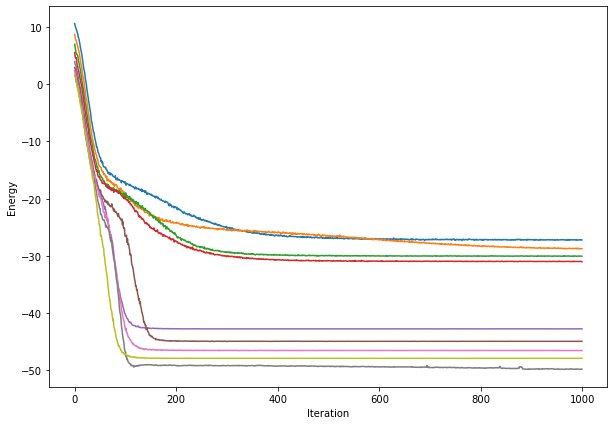

In [28]:
# sept. 2021, overhall the data to prepare a paper

# Check the RBM data
# energy vs iteration: does it converge?

import matplotlib.pyplot as plt
import json

fig, ax1 = plt.subplots(figsize=(10,7))

for angle in range(50,95,5):
    en = []
    st = []

    data=json.load(open("/Users/erhai/Dropbox/NetKet-Compass/RBM-Data/RBM-ITE-"+str(angle)+".log"))

    for iteration in data["Output"]:
        en.append(iteration["Energy"]["Mean"])
        st.append(iteration["Iteration"])

    ax1.plot(st, en)
    
ax1.set_ylabel('Energy')
ax1.set_xlabel('Iteration')
plt.show()


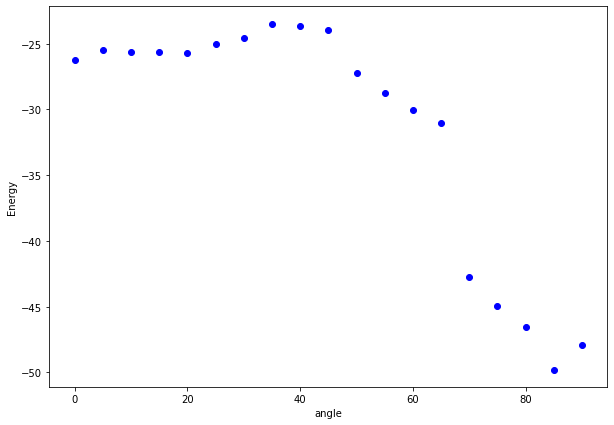

In [21]:
# energy at the end of iteration  vs   angle

en = []
ag = []
    
for angle in range(0,95,5):

    data=json.load(open("/Users/erhai/Dropbox/NetKet-Compass/RBM-Data/RBM-ITE-"+str(angle)+".log"))

    for iteration in data["Output"]:
        if iteration["Iteration"] == 999:
            en.append(iteration["Energy"]["Mean"])
            ag.append(angle)

fig, ax1 = plt.subplots(figsize=(10,7))
ax1.plot(ag, en, 'bo')
ax1.set_ylabel('Energy')
ax1.set_xlabel('angle')
plt.show()

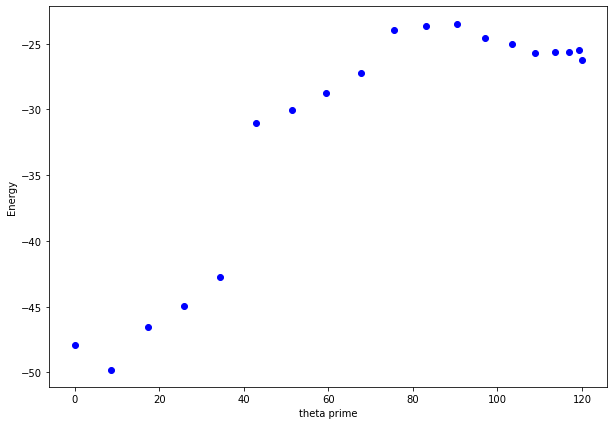

In [22]:
# same plot, but versus theta-prime
import math
ToRadiant = math.pi/180.0
en = []
ag = []
    
for angle in range(0,95,5):

    data=json.load(open("/Users/erhai/Dropbox/NetKet-Compass/RBM-Data/RBM-ITE-"+str(angle)+".log"))

    for iteration in data["Output"]:
        if iteration["Iteration"] == 999:
            en.append(iteration["Energy"]["Mean"])
            th = angle*ToRadiant 
            cs = math.cos(th)
            thetaprime = math.acos(1.0 - 1.5*cs**2)
            ag.append(thetaprime/ToRadiant)

fig, ax1 = plt.subplots(figsize=(10,7))
ax1.plot(ag, en, 'bo')
ax1.set_ylabel('Energy')
ax1.set_xlabel('theta prime')
plt.show()




In [6]:
x = range(3, 20, 2)

In [7]:
x

range(3, 20, 2)